In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from newspaper import Article
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

For the rest of this class I want to brain dump everything we talked about today in class so I have a good idea of what to do going forward.

I need to rethink how accuracy is done:
- Look at volatility for each ticker and determine accurate 1 or not accurate 0 based on the specific ticker rather than the global bounds I defined
- If the row is positive sentiment then for now if the return is positive in the right time frame accuracy is 1 - if need to use volatility for better bounding revisit later after first pass
- same logic if the row is negative sentiment
- if its one of the 20,000 neutral sentiment rows, then whether they are accurate or not depends if the stock price in the right time frame stays within some ticker specific bounds.

Modeling use unsupervised learning - kmeans clustering. Theres 2 aspects to this project clustering and accuracy they are 2 separate things.

Modeling - what would the user like to see:
- For kmeans focus on the sentiment and the ticker and leave the accuracy to be a separate thing (that means drop signal)
- It would be cool to have a general dashboard widget where you can see the clusters of publishers based on their sentiment articles published what else?
- The real deal is a widget showing clustering of tickers

The vision is basically as an investor I look up the ticker im interested in (maybe dropdown of allowed tickers), and I can see the ticker in the cluster and then as a separate thing I can see all the authors that have written about the ticker, how many articles, their accuracy and anything else?

First step is to calculate the volatility for each ticker and then go through and redo the accuracy column
Second step is build multiple clusters
Third step is to turn them into widgets and figure out how to make it interactive select ticker -> show authors sorted by accuracy -> select author and show their stats for that specific ticker. 

In [2]:
data = pd.read_csv('modeling.csv')

In [3]:
volatility_7d = data.groupby("ticker")["return_7d"].std()
volatility_30d = data.groupby("ticker")["return_30d"].std()
volatility_6m = data.groupby("ticker")["return_6m"].std()

In [4]:
data["vol_7d"] = data["ticker"].map(volatility_7d)
data["vol_30d"] = data["ticker"].map(volatility_30d)
data["vol_6m"] = data["ticker"].map(volatility_6m)

In [5]:
def set_accuracy(row):
    sentiment = row["sentiment_encoded"]
    
    if row["long_term"] == 1:
        r = row["return_6m"]
        vol = row["vol_6m"]
        
        if pd.isna(r) or pd.isna(vol):
            return np.nan
        
        if sentiment == 1:   
            return 1 if r > 0 else 0
        elif sentiment == -1:   
            return 1 if r < 0 else 0
        elif sentiment == 0:  
            return 1 if abs(r) < vol else 0

    else:
        r30 = row["return_30d"]
        r7 = row["return_7d"]
        vol30 = row["vol_30d"]
        vol7 = row["vol_7d"]
        
        if pd.isna(r30) or pd.isna(r7) or pd.isna(vol30) or pd.isna(vol7):
            return np.nan
        
        if abs(r30) < vol30:
            r = r7
            vol = vol7
        else:
            r = r30
            vol = vol30
        
        if sentiment == 1:   
            return 1 if r > 0 else 0
        elif sentiment == -1:   
            return 1 if r < 0 else 0
        elif sentiment == 0:   
            return 1 if abs(r) < vol else 0
    
    return np.nan

data["accuracy"] = data.apply(set_accuracy, axis=1)

In [6]:
data["accuracy"].value_counts()

accuracy
1.0    13910
0.0     9997
Name: count, dtype: int64

Now I am going to move onto the clustering we talked about so I can do the widgets

In [7]:
ticker_features = data.groupby('ticker').agg({
    'sentiment_encoded': 'mean',
    'return_30d': 'mean',
    'return_6m': 'mean',
    'vol_30d': 'mean',
    'headline': 'count'
}).rename(columns={
    'sentiment_encoded': 'avg_sentiment',
    'headline': 'article_count'
})

ticker_features = ticker_features.reset_index()

In [8]:
features = ticker_features[['avg_sentiment', 'return_30d']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

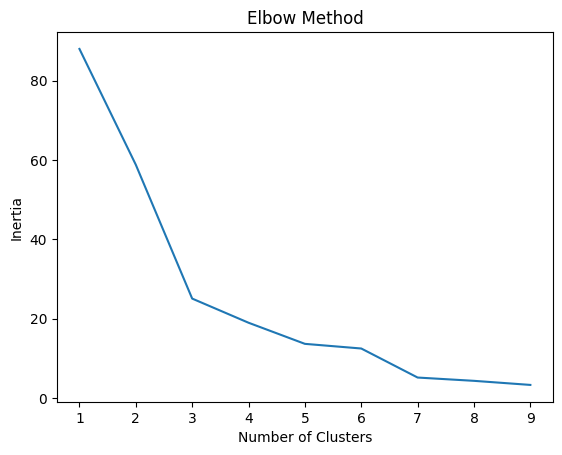

In [9]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
ticker_features['cluster'] = kmeans.fit_predict(X_scaled)

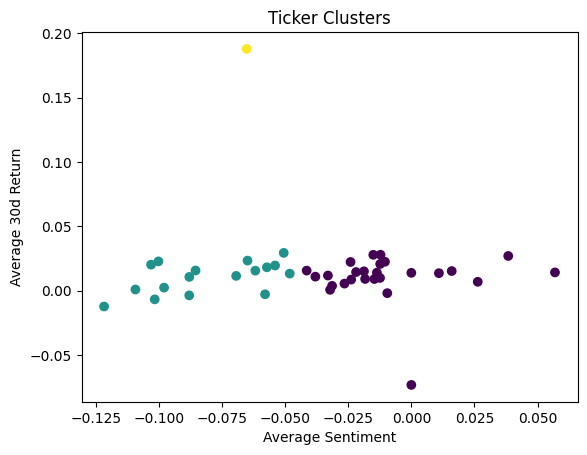

In [11]:
plt.scatter(
    ticker_features['avg_sentiment'],
    ticker_features['return_30d'],
    c=ticker_features['cluster']
)

plt.xlabel("Average Sentiment")
plt.ylabel("Average 30d Return")
plt.title("Ticker Clusters")
plt.show()

In [12]:
ticker_features[['ticker','avg_sentiment','return_30d','cluster']].sort_values('cluster')

,ticker,avg_sentiment,return_30d,cluster
0,ADBE,-0.024077,0.022227,0
1,AIG,-0.032184,0.000603,0
2,AMD,0.026316,0.006834,0
3,AVGO,-0.010453,0.022404,0
4,AXP,-0.026490,0.005432,0
5,AZN,-0.031390,0.003697,0
6,BABA,-0.033037,0.011707,0
8,BIIB,-0.009524,-0.001983,0
13,COP,-0.023810,0.008570,0
9,BMY,0.010929,0.013540,0


I want to build a more extensive model for the tickers:

avg_sentiment - mean sentiment for ticker
sentement_std - sentiment variability
bullish_rate - % positive articles for ticker
bearish_rate - % negative articles for ticker
neutral_rate - % neutral articles for ticker (may have to remove these 3 because I expect them to be the same mostly but we will see)
returns for 7,30, and 6month
volatility per ticker
article count for news coverage on each ticker
long term - short term v longterm coverage on a ticker

In [ ]:
ticker_features = data.groupby('ticker').agg(
    avg_sentiment=('sentiment_encoded', 'mean'),
    sentiment_std=('sentiment_encoded', 'std'),
    bullish_rate=('sentiment_encoded', lambda x: (x == 1).mean()),
    bearish_rate=('sentiment_encoded', lambda x: (x == -1).mean()),
    avg_return_30d=('return_30d', 'mean'),
    avg_return_6m=('return_6m', 'mean'),
    vol_30d=('return_30d', 'std'),
    article_count=('headline', 'count'),
    long_term_ratio=('long_term', 'mean')
).reset_index()

In [31]:
ticker_features['sentiment_std'] = ticker_features['sentiment_std'].fillna(0)
ticker_features['vol_30d'] = ticker_features['vol_30d'].fillna(0)

In [32]:
features = ticker_features.drop(columns=['ticker'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

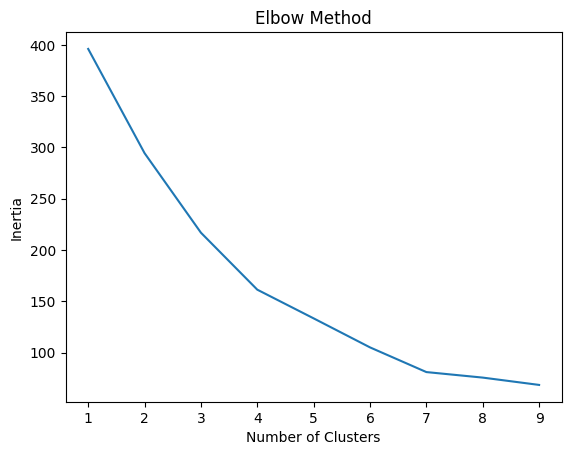

In [33]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42)
ticker_features['cluster'] = kmeans.fit_predict(X_scaled)

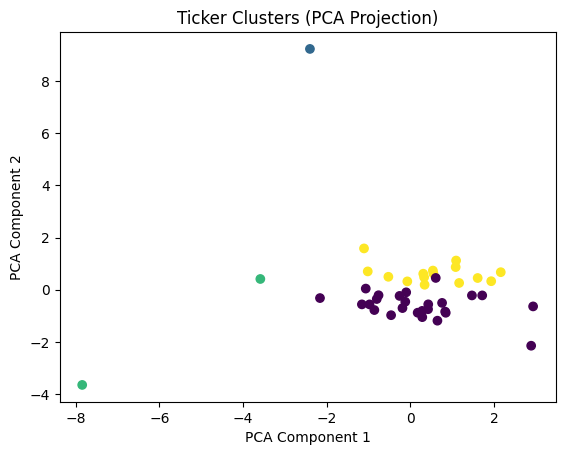

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=ticker_features['cluster']
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Ticker Clusters (PCA Projection)")
plt.show()

In [38]:
silhouette_score(X_scaled, ticker_features['cluster'])

0.25197287868742974

In [40]:
cluster_summary = ticker_features.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         avg_sentiment  sentiment_std  bullish_rate  bearish_rate  \
cluster                                                             
0            -0.015333       0.439631      0.090234      0.105567   
1            -0.065217       0.372282      0.038647      0.103865   
2             0.013158       0.162761      0.032895      0.019737   
3            -0.083205       0.454467      0.065766      0.148972   

         avg_return_30d  avg_return_6m   vol_30d  article_count  \
cluster                                                           
0              0.014145       0.092472  0.073467     553.730769   
1              0.187762       1.791052  0.340094     414.000000   
2             -0.033226       0.182320  0.073454      38.500000   
3              0.009282       0.087942  0.115368     601.333333   

         long_term_ratio  
cluster                   
0               0.106690  
1               0.036232  
2               0.026316  
3               0.095255  


Cluster 1 is high return, high volatility, well covered stocks
Cluster 2 is low coverage mixed performance stocks
Cluster 0 is stable volatality moderate return well covered
Cluster 3 is well covered with stronger sentiment swings

In [41]:
data.to_csv('data_visualization.csv', index=False)